In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/train_processed.csv')

X = df.drop(columns=['isFraud'])
y = df['isFraud']

# Use a sample for SHAP (full dataset is too slow on CPU)
X_sample = X.sample(n=5000, random_state=42)
y_sample = y[X_sample.index]

# Load XGBoost model
xgb_model = joblib.load('../models/xgb_model.pkl')

print(f"Sample shape: {X_sample.shape}")


Sample shape: (5000, 434)


In [3]:
print("Computing SHAP values... (3-5 mins on CPU)")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")


Computing SHAP values... (3-5 mins on CPU)
SHAP values shape: (5000, 434)


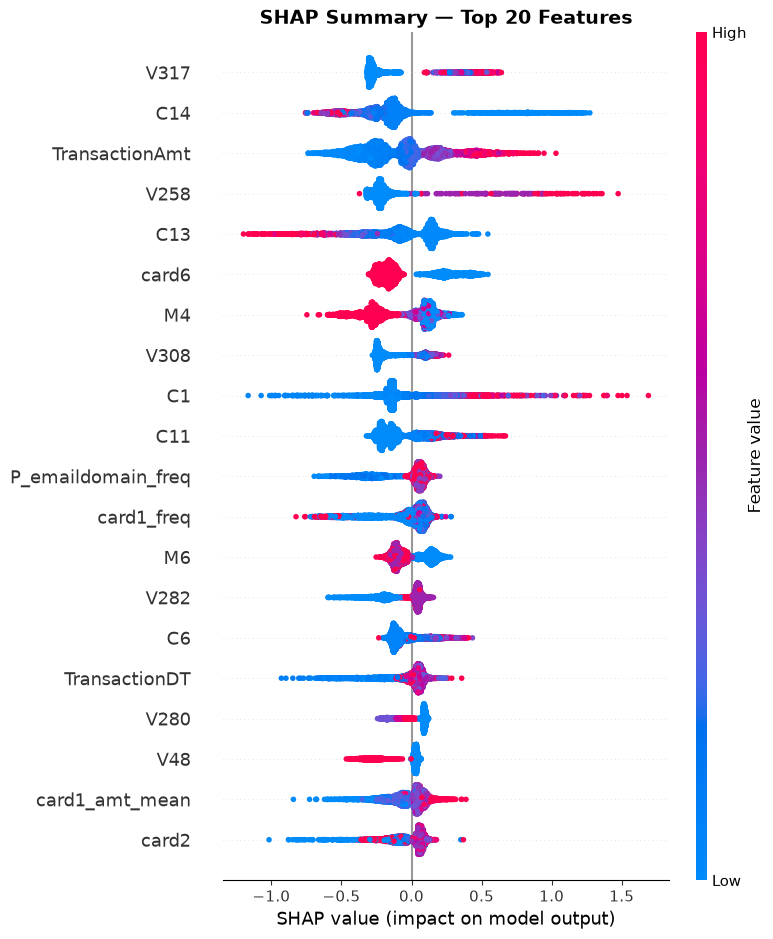

In [4]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20,
    show=False
)
plt.title("SHAP Summary — Top 20 Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

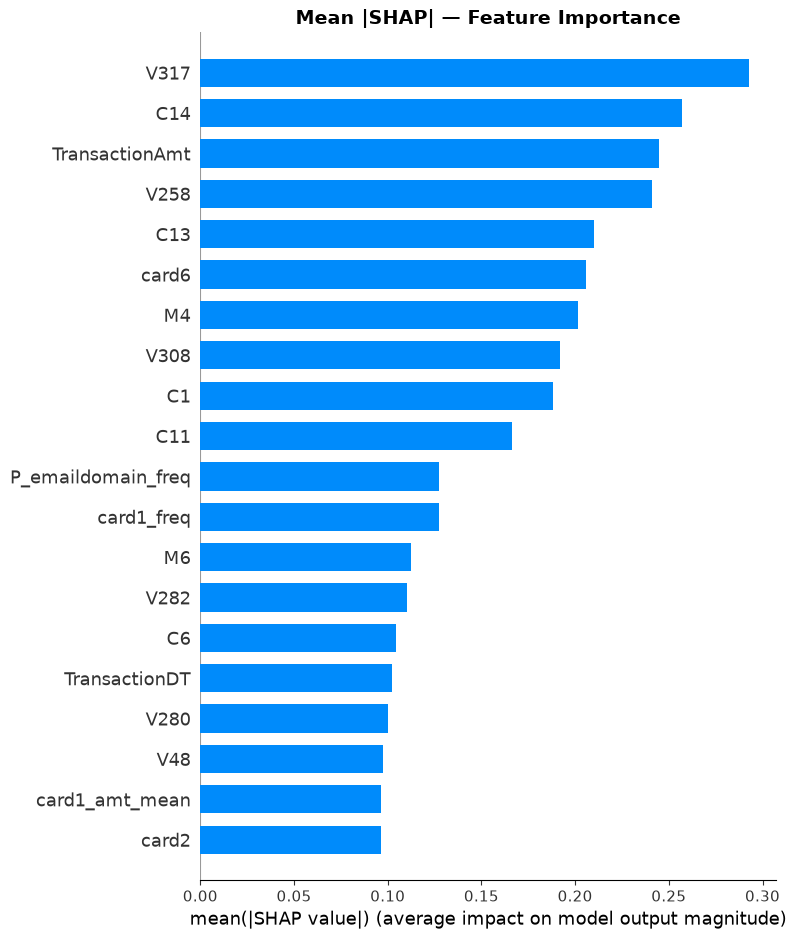

In [5]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Mean |SHAP| — Feature Importance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Top feature: V317


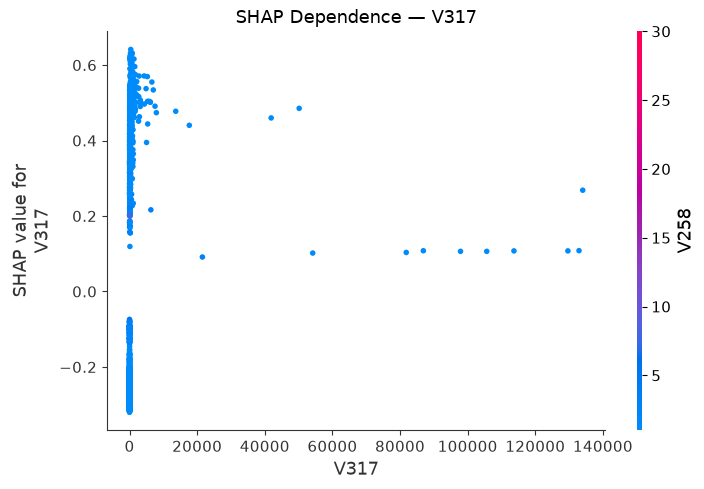

In [6]:
# Get top feature by mean |SHAP|
top_feature = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).idxmax()

print(f"Top feature: {top_feature}")

shap.dependence_plot(
    top_feature,
    shap_values,
    X_sample,
    show=False
)
plt.title(f"SHAP Dependence — {top_feature}", fontsize=13)
plt.tight_layout()
plt.savefig('../models/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining transaction ID: 370788


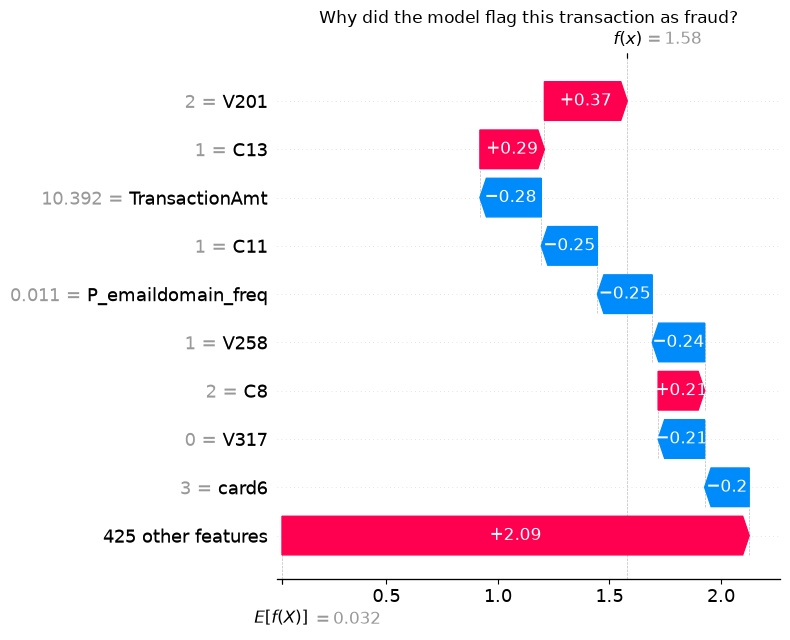

In [7]:
# Pick a fraud transaction from sample
fraud_idx = y_sample[y_sample == 1].index[0]
fraud_sample = X_sample.loc[[fraud_idx]]

print(f"Explaining transaction ID: {fraud_idx}")

shap.waterfall_plot(
    shap.Explanation(
        values      = shap_values[X_sample.index.get_loc(fraud_idx)],
        base_values = explainer.expected_value,
        data        = fraud_sample.values[0],
        feature_names = X_sample.columns.tolist()
    ),
    show=False
)
plt.title("Why did the model flag this transaction as fraud?", fontsize=12)
plt.tight_layout()
plt.savefig('../models/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining transaction ID: 470624


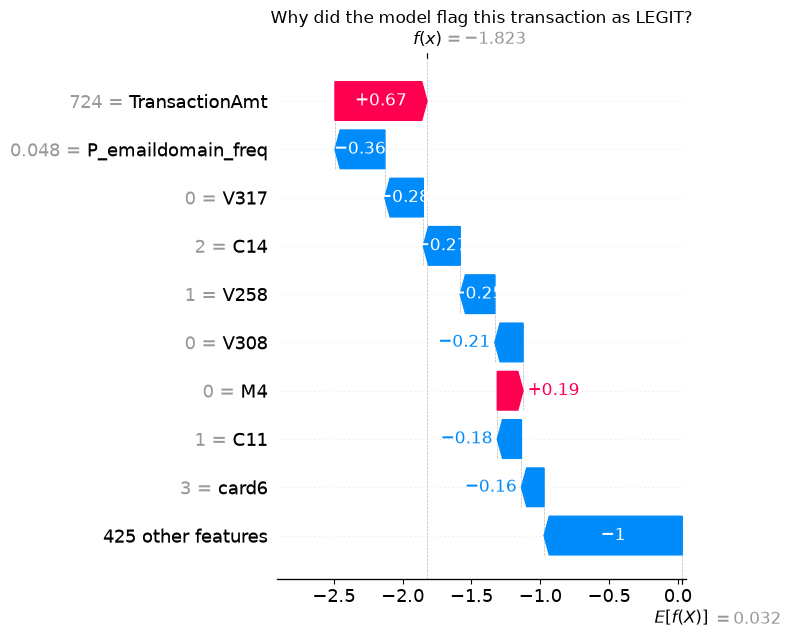

In [9]:
# Pick a legit transaction
legit_idx = y_sample[y_sample == 0].index[0]
legit_sample = X_sample.loc[[legit_idx]]

print(f"Explaining transaction ID: {legit_idx}")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[X_sample.index.get_loc(legit_idx)],
        base_values   = explainer.expected_value,
        data          = legit_sample.values[0],
        feature_names = X_sample.columns.tolist()
    ),
    show=False
)
plt.title("Why did the model flag this transaction as LEGIT?", fontsize=12)
plt.tight_layout()
plt.savefig('../models/shap_waterfall_legit.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
shap_importance = pd.DataFrame({
    'feature'        : X_sample.columns,
    'mean_abs_shap'  : np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(10).reset_index(drop=True)

shap_importance.index += 1  # start from 1
print("\n🔍 Top 10 Most Important Features (SHAP):")
print(shap_importance.to_string())

shap_importance.to_csv('../models/shap_top10_features.csv', index=False)


🔍 Top 10 Most Important Features (SHAP):
           feature  mean_abs_shap
1             V317       0.292574
2              C14       0.256793
3   TransactionAmt       0.244955
4             V258       0.241235
5              C13       0.210174
6            card6       0.205686
7               M4       0.201688
8             V308       0.192192
9               C1       0.188185
10             C11       0.166552
